<a href="https://colab.research.google.com/github/Khanbir/Data_analitycs/blob/main/DZ_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - сезон (1=весна, 2=літо, 3=осінь, 4=зима)
    
    
  **ПОМИЛКА - 1=зима, 2=весна, 3=літо, 4=осінь**

- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/DATA-ANALITICS_ Pylieva/yulu_bike_sharing_dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [17]:
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,...,day,week,weekday_num,weekday,year,month,hour,month_year,weather_label,season_label
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,...,1,52,5,Saturday,2011,1,0,2011-01,Ясно,Зима
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,...,1,52,5,Saturday,2011,1,1,2011-01,Ясно,Зима
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,...,1,52,5,Saturday,2011,1,2,2011-01,Ясно,Зима
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,...,1,52,5,Saturday,2011,1,3,2011-01,Ясно,Зима
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,...,1,52,5,Saturday,2011,1,4,2011-01,Ясно,Зима



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [5]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

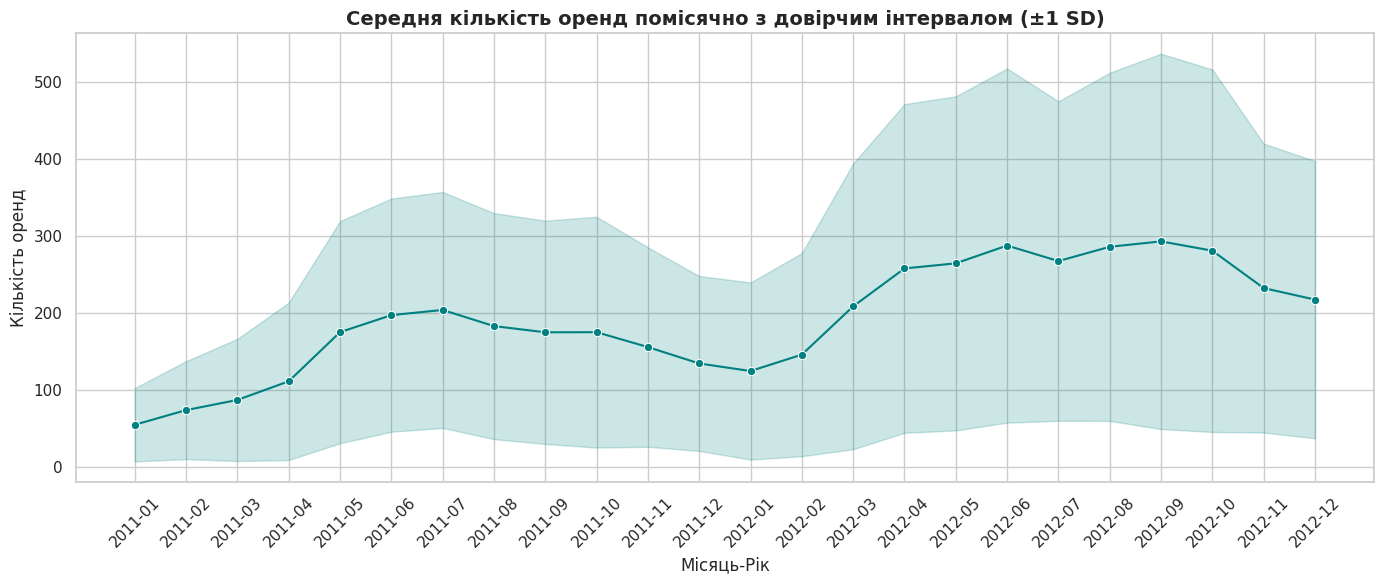

In [6]:
# Побудова графіка
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='month_year', y='count', errorbar='sd', marker='o', color='teal')
# Оформлення
plt.xticks(rotation=45)
plt.title('Середня кількість оренд помісячно з довірчим інтервалом (±1 SD)', fontsize=14, fontweight='bold')
plt.xlabel('Місяць-Рік')
plt.ylabel('Кількість оренд')
plt.grid(True)
plt.tight_layout()
plt.show()


В які місяці найбільша невизначеність в даних?

Невизначеність визначаємо по тіні навколо лінії... чим більша тінь тим більша невизначеність... згідно нашого графіку найбільша невизначеність становить 6, 8 - 10 місяці 2012 року.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

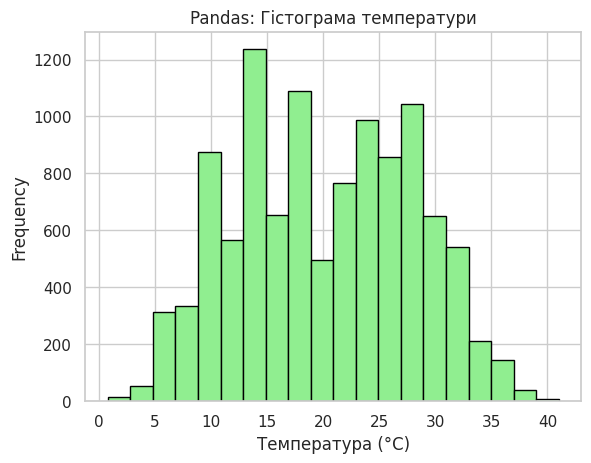

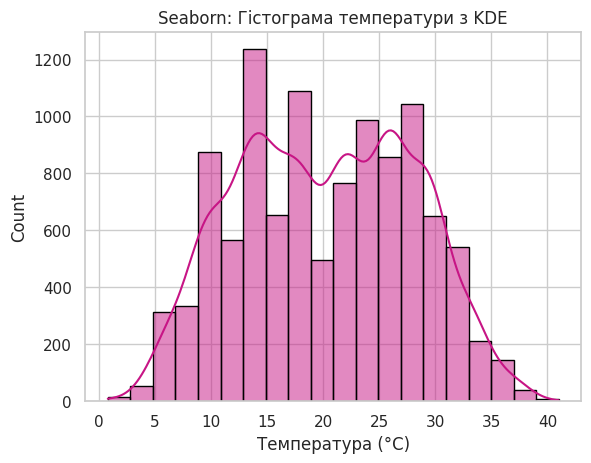

In [7]:
df['temp'].plot.hist(bins=20, color='lightgreen', edgecolor='black', title='Pandas: Гістограма температури')
plt.xlabel('Температура (°C)')
plt.grid(True)
plt.show()

## побудова гістограми
sns.histplot(data=df, x='temp', bins=20, kde=True, color='mediumvioletred', edgecolor='black')
plt.title('Seaborn: Гістограма температури з KDE')
plt.xlabel('Температура (°C)')
plt.grid(True)
plt.show()


Лінія KDE - це крива щільності.
Що відображає оцінку густини ймовірності: гладка лінія, що показує імовірність появи певного значення.
Вона згладжує розподіл та дозволяє краще оцінити "форму" даних, ніж просто стовпчики.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

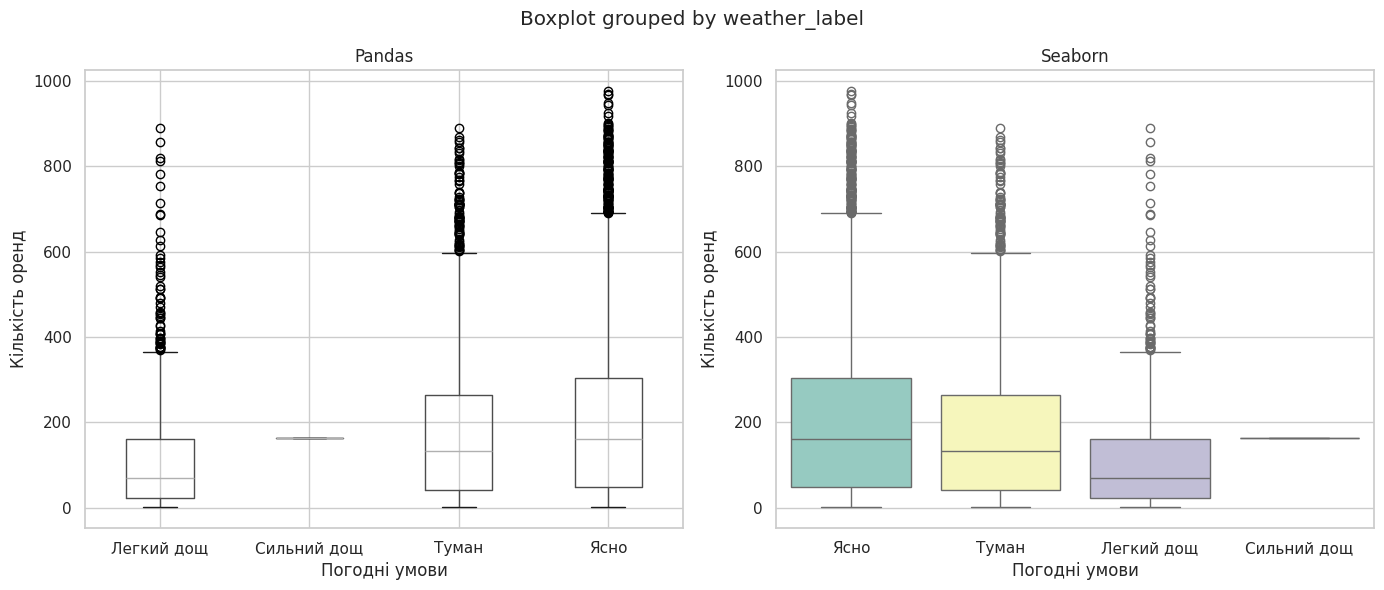

In [8]:
# Перекладаємо значення weather у підписи
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}
df['weather_label'] = df['weather'].map(weather_labels)

# Побудова фігури
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Box Plot кількості оренд по погоді: Pandas vs Seaborn', fontsize=14, fontweight='bold')

# Pandas Boxplot
df.boxplot(column='count', by='weather_label', ax=axs[0], grid=True)
axs[0].set_title('Pandas')
axs[0].set_xlabel('Погодні умови')
axs[0].set_ylabel('Кількість оренд')

# Seaborn Boxplot
sns.boxplot(data=df, x='weather_label', y='count', hue='weather_label', palette='Set3', legend=False, ax=axs[1])
axs[1].set_title('Seaborn')
axs[1].set_xlabel('Погодні умови')
axs[1].set_ylabel('Кількість оренд')

# Оформлення
plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Щоб suptitle не перекривався
plt.show()



Різниця в Пандас - вигляд - мінімалістичний - однотонний. Графік менш гнучкий!

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


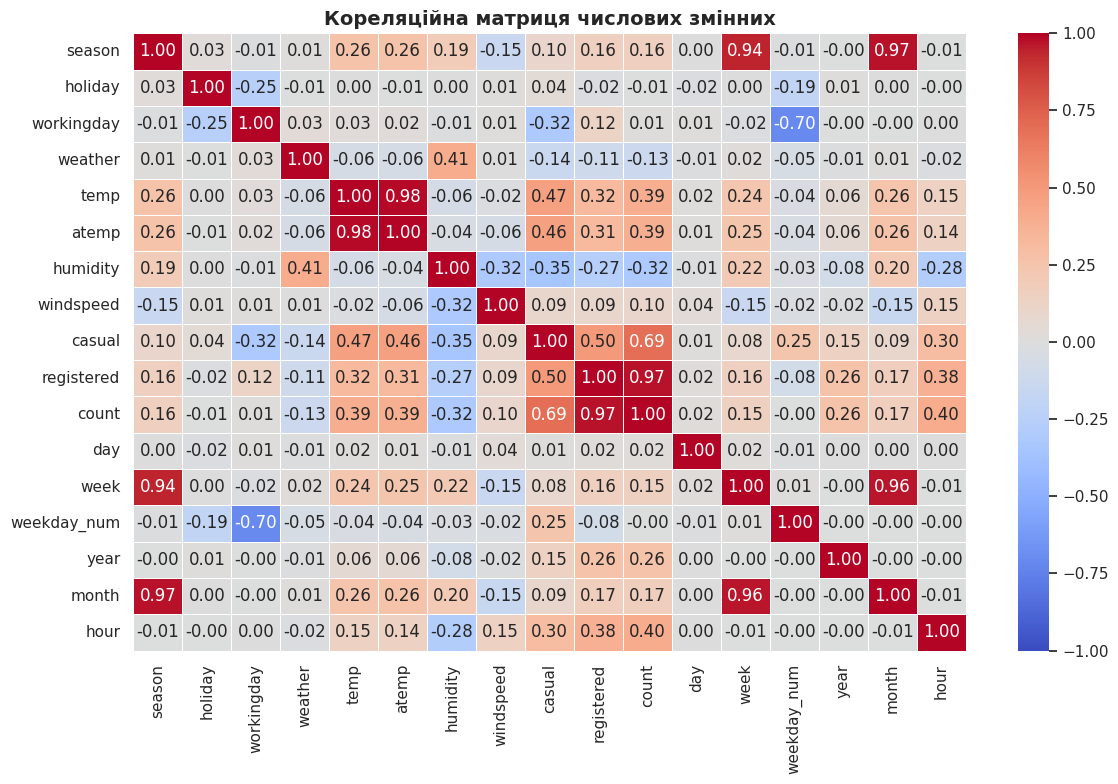

In [9]:
##Створення матриці
corr_matrix = df.corr(numeric_only=True)
## Побудова heatmap з анотаціями
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Кореляційна матриця числових змінних', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 Відповіді на питання по графіку:

Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
найсельніше корелюють  - registered

Яка кореляція між temp та atemp? Чому?
Кореляція - 0.98 — практично ідеальний зв’язок. Це логічно, бо "atemp" — це відчуття температури, а "temp" — фактична.

Які змінні мають негативну кореляцію?
weekday_num - workingday
casual - humidity

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за сезонами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому сезоні найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


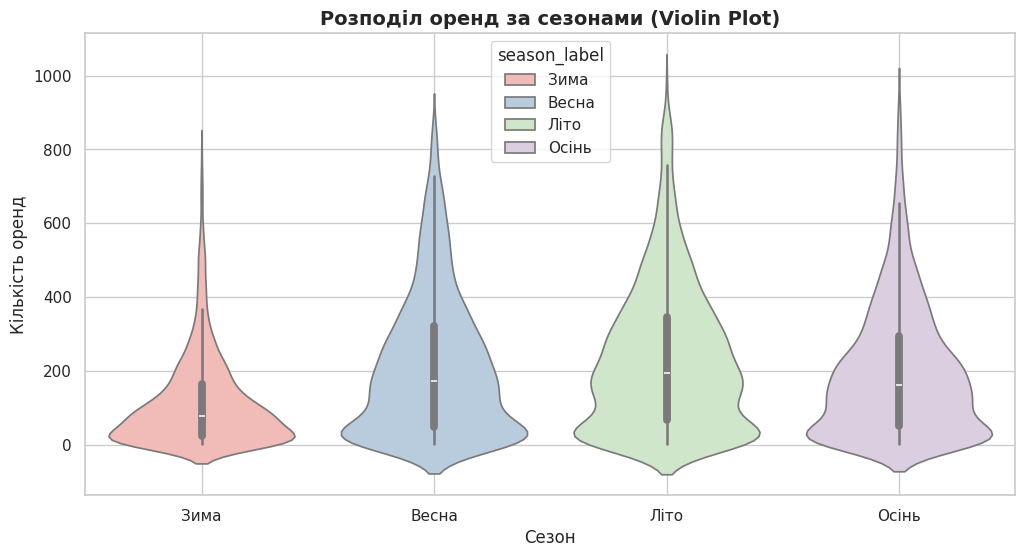

In [10]:
season_labels = {1: 'Зима', 2: 'Весна', 3: 'Літо', 4: 'Осінь'}
df['season_label'] = df['season'].map(season_labels)

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season_label', y='count', hue='season_label', palette='Pastel1', legend=True)
plt.title('Розподіл оренд за сезонами (Violin Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Сезон')
plt.ylabel('Кількість оренд')
plt.grid(True)
plt.show()


1. "Товщина" графіка відображає густину розподілу значень:

Де графік ширший — там більше даних у цій ділянці.

Це фактично оцінка щільності розподілу: згладжене уявлення про те, як часто трапляються значення певного рівня.

2.  Найбільша варіабельність спостерігається влітку (Літо):

Форма скрипки широка по всій вертикалі, що свідчить про велику змінність у кількості оренд.

Влітку оренди варіюються від дуже низьких до дуже високих значень — активна сезонність.

3. Violin Plot показує все те ж саме, що box plot але плюс до того ще щільність розподілу (як розподілені значення всередині діапазону);модальність (чи є один чи кілька піків) та симетрію або перекіс розподілу.
Взагалі - дає кращу візуальну уяву про характер вибірки.

## Завдання 6: Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте сезон.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше змінюється від сезону?

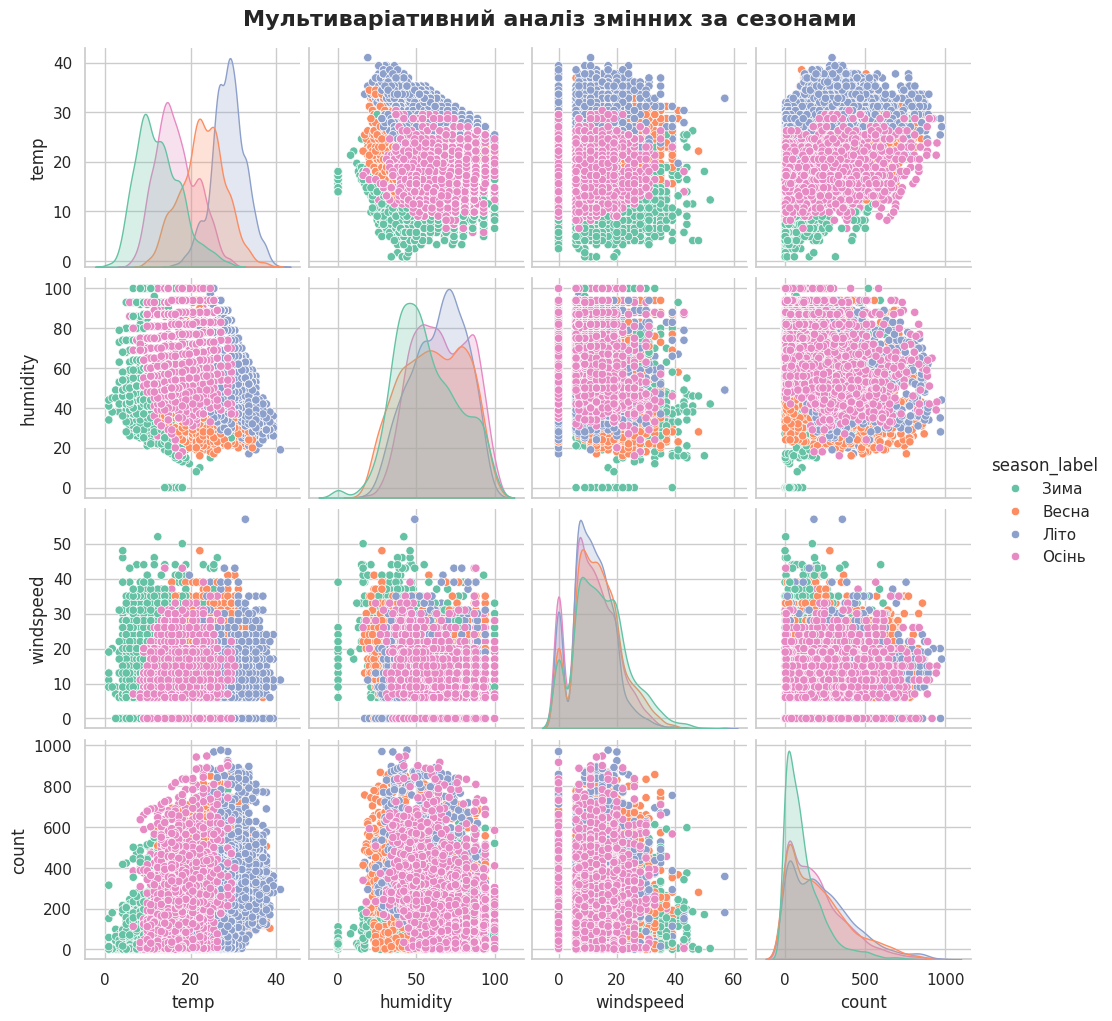

In [14]:
sns.pairplot(df, vars=['temp', 'humidity', 'windspeed', 'count'], hue='season_label', palette='Set2')
plt.suptitle('Мультиваріативний аналіз змінних за сезонами', fontsize=16, fontweight='bold', y=1.02)
plt.show()


1. Найсильніший лінійний зв’язок: між 'temp' та 'count'
Температура — головний фактор, що впливає на кількість оренд.
Сезонність очевидна:
Влітку — найвищий попит,
Взимку — найнижчий.

2. Найбільше змінюється від сезону також температура. Остальні характеристика не мають таких більшвиражених змін і залежностей від сезону.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

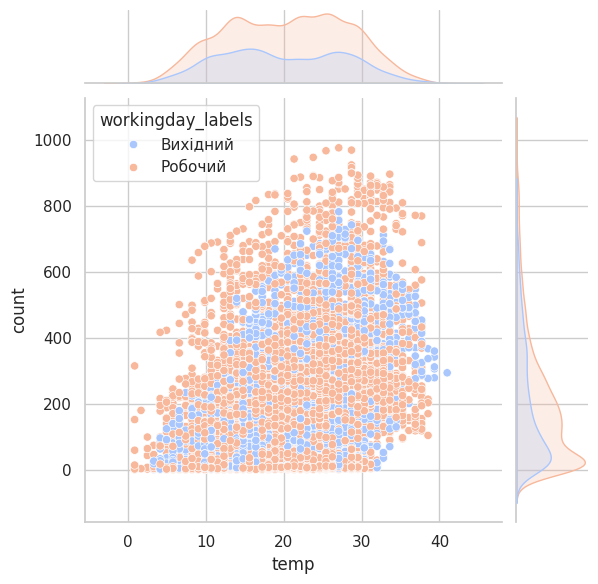

In [18]:
workingday_labels = {0: 'Вихідний', 1: 'Робочий'}
df['workingday_labels'] = df['workingday'].map(workingday_labels)
sns.jointplot(data=df, x='temp', y='count', hue='workingday_labels', kind='scatter', palette='coolwarm')
plt.show()

Що показують графіки по краях?
Графіки по краях — розподіли (гістограми) кожної змінної окремо.

  Верхній графік (ось X — temp):
Показує розподіл температур окремо для робочих (оранжевий) та вихідних (синій) днів.
Обидва розподіли подібні: температура однаково варіюється і в робочі, і у вихідні дні.

  
  Правий графік (ось Y — count):
Показує розподіл кількості оренд велосипедів (count) за типом дня.
Оранжевий (робочий день) має ширший та вищий пік — тобто, в робочі дні оренд більше, особливо в діапазоні 400–700.


Чи є різниця у поведінці користувачів у робочий і неробочий день?

  Видно різницю між робочими і неробочими днями: у неробочі дні більше випадкових оренд, особливо при теплій погоді.
  
  Ймовірно, у робочі дні більше регулярних поїздок (наприклад, на роботу), тоді як у вихідні — поїздки менш регулярні та менш масові